<a href="https://colab.research.google.com/github/MarcGaac/Stat-Theory/blob/main/SA_1_dataware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part I: Employee Dimension (Slowly Changing Dimensions)

Type 0: Retain Original
The dimension retains the original attribute values and ignores all subsequent changes.
| EmployeeID | Name | Salary |
| :--- | :--- | :--- |
| A1 | Adam | 3900 |
| B2 | Ben | 4000 |

Type 1: Overwrite
The dimension is updated by overwriting the old data. No historical context is kept.
| EmployeeID | Name | Salary |
| :--- | :--- | :--- |
| A1 | Adam | 5500 |
| B2 | Ben | 4750 |

Type 2: Add New Row
A new row is inserted for every change. Requires a Surrogate Key (SK) and validity flags.
| SK | EmployeeID | Name | Salary | StartDate | EndDate | IsCurrent |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | A1 | Adam | 3900 | 2016-03-01 | 2016-05-31 | N |
| 2 | A1 | Adam | 4300 | 2016-06-01 | 2016-12-31 | N |
| 3 | A1 | Adam | 5000 | 2017-01-01 | 2017-06-30 | N |
| 4 | A1 | Adam | 5500 | 2017-07-01 | NULL | Y |
| 5 | B2 | Ben | 4000 | 2017-02-01 | 2017-05-31 | N |
| 6 | B2 | Ben | 4750 | 2017-06-01 | NULL | Y |

Type 3: Add New Attribute
A new column keeps the immediate previous value, losing older history.
| EmployeeID | Name | Current_Salary | Previous_Salary |
| :--- | :--- | :--- | :--- |
| A1 | Adam | 5500 | 5000 |
| B2 | Ben | 4750 | 4000 |

Type 4: History Table
Separates the latest state from the historical records into two distinct tables.

Current Table:
| EmployeeID | Name | Salary |
| :--- | :--- | :--- |
| A1 | Adam | 5500 |
| B2 | Ben | 4750 |

History Table:
| EmployeeID | Salary | StartDate | EndDate |
| :--- | :--- | :--- | :--- |
| A1 | 3900 | 2016-03-01 | 2016-05-31 |
| A1 | 4300 | 2016-06-01 | 2016-12-31 |
| A1 | 5000 | 2017-01-01 | 2017-06-30 |
| B2 | 4000 | 2017-02-01 | 2017-05-31 |

Type 6: Hybrid (1 + 2 + 3)
Adds a new row for each change (Type 2), keeps historical/current columns (Type 3), and overwrites the Current_Salary for all historical rows to ensure it's up-to-date (Type 1).
| SK | EmployeeID | Name | Historical_Salary | Current_Salary | StartDate | EndDate | IsCurrent |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | A1 | Adam | 3900 | 5500 | 2016-03-01 | 2016-05-31 | N |
| 2 | A1 | Adam | 4300 | 5500 | 2016-06-01 | 2016-12-31 | N |
| 3 | A1 | Adam | 5000 | 5500 | 2017-01-01 | 2017-06-30 | N |
| 4 | A1 | Adam | 5500 | 5500 | 2017-07-01 | NULL | Y |
| 5 | B2 | Ben | 4000 | 4750 | 2017-02-01 | 2017-05-31 | N |
| 6 | B2 | Ben | 4750 | 4750 | 2017-06-01 | NULL | Y |

Part II: Telecom Billing System
1. The Five Summary Tables (Sample Data)
Table 1 – Calls by Rate Type
| Rate Type | Number of Calls | Total Duration (minutes) |
| :--- | :--- | :--- |
| Peak | 45,200 | 185,500.00 |
| Off Peak | 31,800 | 240,100.00 |

Table 2 – Calls by Call Type
| Call Type | Number of Calls | Total Duration (minutes) |
| :--- | :--- | :--- |
| National (Landline) | 8,500 | 65,000.00 |
| Mobile to Globe | 32,000 | 150,200.00 |
| Mobile to Smart | 25,500 | 135,400.00 |
| Mobile to DITO | 11,000 | 75,000.00 |

Table 3 – Calls by Location
| Location | Number of Calls | Total Duration (minutes) |
| :--- | :--- | :--- |
| Quezon City | 18,500 | 105,000.00 |
| Makati City | 28,000 | 145,500.00 |
| Baguio City | 5,200 | 32,000.00 |
| Davao City | 14,300 | 85,100.00 |
| Cebu City | 11,000 | 58,000.00 |

Table 4 – Calls by Date
| Date | Number of Calls | Total Duration (minutes) |
| :--- | :--- | :--- |
| June 15, 2025 | 18,500 | 102,500.00 |
| June 16, 2025 | 19,200 | 108,000.00 |
| June 17, 2025 | 20,100 | 110,600.00 |
| June 18, 2025 | 19,200 | 104,500.00 |

Table 5 – Calls by Time Category
| Time Category | Number of Calls | Total Duration (minutes) |
| :--- | :--- | :--- |
| Morning (6 AM–12 NN) | 22,000 | 110,000.00 |
| Afternoon (12 NN–6 PM) | 28,500 | 145,000.00 |
| Evening (6 PM–12 MN) | 18,500 | 125,600.00 |
| Late Night (12 MN–6 AM) | 8,000 | 45,000.00 |

 Database Creation (DDL Scripts)

In [6]:
import sqlite3

# Assuming 'conn' is your sqlite3 connection object
sql_query = """
-- Create Dimension Tables
CREATE TABLE IF NOT EXISTS DIM_DATE (
    Date_Key INT PRIMARY KEY,
    FullDate DATE,
    DayOfWeek VARCHAR(15),
    Month VARCHAR(15),
    Year INT
);

CREATE TABLE IF NOT EXISTS DIM_TIME (
    Time_Key INT PRIMARY KEY,
    TimeCategory VARCHAR(50)
);

CREATE TABLE IF NOT EXISTS DIM_LOCATION (
    Location_Key INT PRIMARY KEY,
    City VARCHAR(100),
    Region VARCHAR(100)
);

CREATE TABLE IF NOT EXISTS DIM_CALL_TYPE (
    CallType_Key INT PRIMARY KEY,
    NetworkType VARCHAR(50)
);

CREATE TABLE IF NOT EXISTS DIM_RATE_TYPE (
    RateType_Key INT PRIMARY KEY,
    RateCategory VARCHAR(20)
);

-- Create Fact Table
CREATE TABLE IF NOT EXISTS FACT_CALLS (
    Call_ID INT PRIMARY KEY,
    Date_Key INT,
    Time_Key INT,
    Location_Key INT,
    CallType_Key INT,
    RateType_Key INT,
    Duration_Minutes DECIMAL(10, 2),

    FOREIGN KEY (Date_Key) REFERENCES DIM_DATE(Date_Key),
    FOREIGN KEY (Time_Key) REFERENCES DIM_TIME(Time_Key),
    FOREIGN KEY (Location_Key) REFERENCES DIM_LOCATION(Location_Key),
    FOREIGN KEY (CallType_Key) REFERENCES DIM_CALL_TYPE(CallType_Key),
    FOREIGN KEY (RateType_Key) REFERENCES DIM_RATE_TYPE(RateType_Key)
);
"""

try:
    conn.executescript(sql_query)
    print("Tables created successfully!")
except Exception as e:
    print(f"Error: {e}")

Tables created successfully!


4. Analytical Queries to Generate the Summary Tables

In [11]:
import pandas as pd

# List of analytical queries
queries = {
    "Calls by Rate Type": """
    SELECT
        d.RateCategory AS [Rate Type],
        COUNT(f.Call_ID) AS [Number of Calls],
        SUM(f.Duration_Minutes) AS [Total Duration (minutes)]
    FROM FACT_CALLS f
    JOIN DIM_RATE_TYPE d ON f.RateType_Key = d.RateType_Key
    GROUP BY d.RateCategory;
    """,
    "Calls by Call Type": """
    SELECT
        d.NetworkType AS [Call Type],
        COUNT(f.Call_ID) AS [Number of Calls],
        SUM(f.Duration_Minutes) AS [Total Duration (minutes)]
    FROM FACT_CALLS f
    JOIN DIM_CALL_TYPE d ON f.CallType_Key = d.CallType_Key
    GROUP BY d.NetworkType;
    """,
    "Calls by Location": """
    SELECT
        d.City AS [Location],
        COUNT(f.Call_ID) AS [Number of Calls],
        SUM(f.Duration_Minutes) AS [Total Duration (minutes)]
    FROM FACT_CALLS f
    JOIN DIM_LOCATION d ON f.Location_Key = d.Location_Key
    GROUP BY d.City;
    """,
    "Calls by Date": """
    SELECT
        d.FullDate AS [Date],
        COUNT(f.Call_ID) AS [Number of Calls],
        SUM(f.Duration_Minutes) AS [Total Duration (minutes)]
    FROM FACT_CALLS f
    JOIN DIM_DATE d ON f.Date_Key = d.Date_Key
    GROUP BY d.FullDate;
    """,
    "Calls by Time Category": """
    SELECT
        d.TimeCategory AS [Time Category],
        COUNT(f.Call_ID) AS [Number of Calls],
        SUM(f.Duration_Minutes) AS [Total Duration (minutes)]
    FROM FACT_CALLS f
    JOIN DIM_TIME d ON f.Time_Key = d.Time_Key
    GROUP BY d.TimeCategory;
    """
}

# Execute each query and display results
for title, sql in queries.items():
    print(f"\n--- {title} ---")
    try:
        results_df = pd.read_sql_query(sql, conn)
        display(results_df)
    except Exception as e:
        print(f"Error executing query: {e}")


--- Calls by Rate Type ---


,Rate Type,Number of Calls,Total Duration (minutes)



--- Calls by Call Type ---


,Call Type,Number of Calls,Total Duration (minutes)



--- Calls by Location ---


,Location,Number of Calls,Total Duration (minutes)



--- Calls by Date ---


,Date,Number of Calls,Total Duration (minutes)



--- Calls by Time Category ---


,Time Category,Number of Calls,Total Duration (minutes)


Star schema

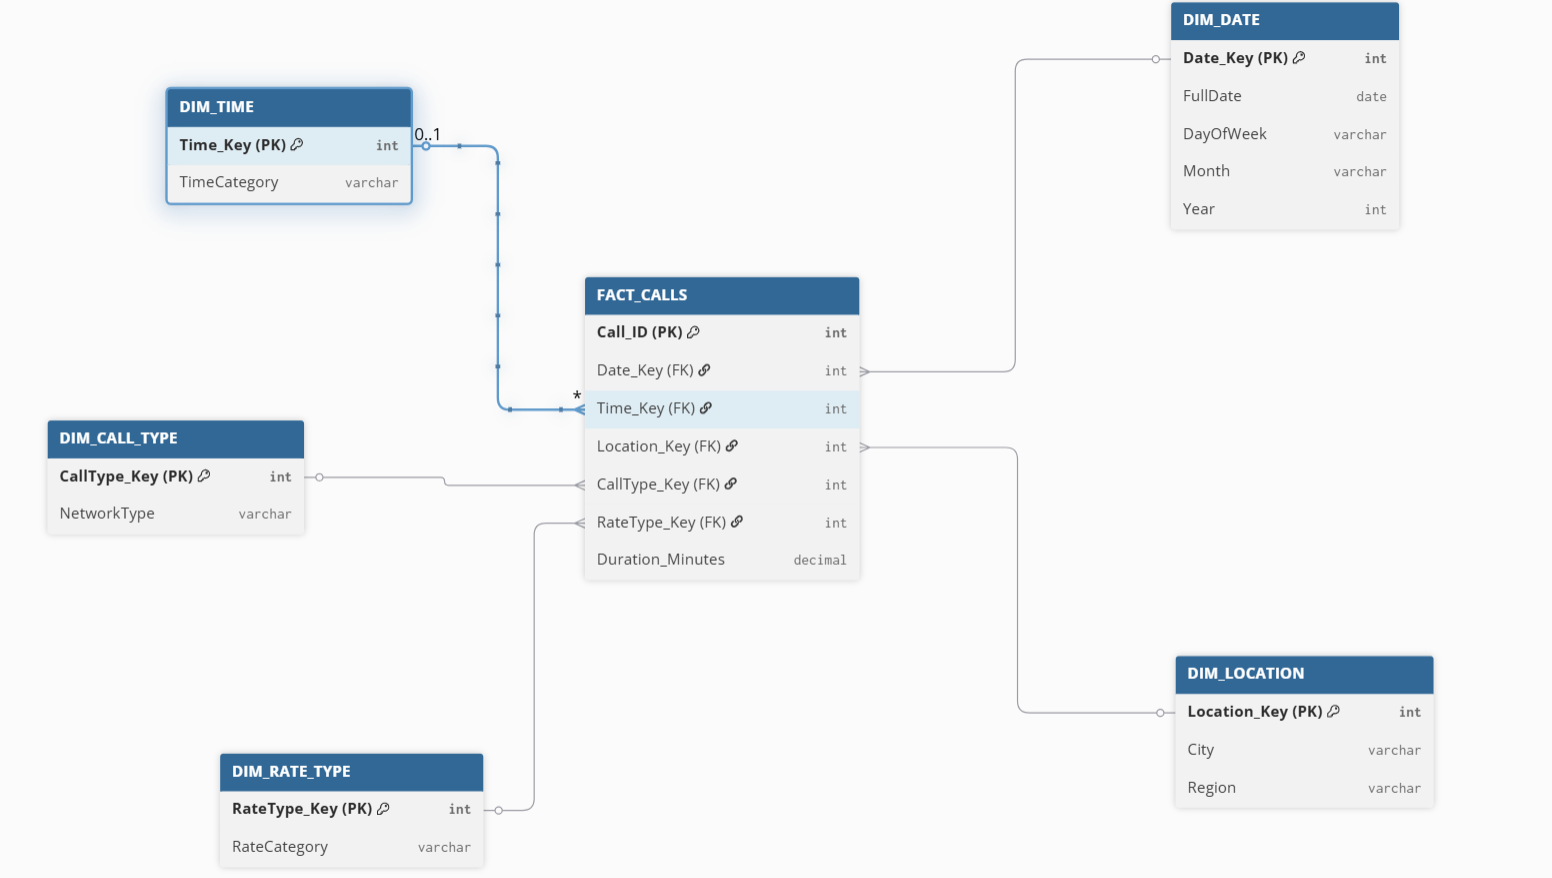